# COM 837 Assignment 2, Q1
### SVM for LOS/NLOS identification

Run `generate_dataset.py` first so `los_nlos_dataset.csv` is in this folder.
Written observations for every part are in the PDF report.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

L = 6                                    # taps per realisation
SNR_LIST = [0, 5, 10, 15, 20, 25, 30]
SEED = 42

df = pd.read_csv('los_nlos_dataset.csv')
df.shape

(14000, 20)

## Part (a) - five features per realisation

In [15]:
# tap amplitudes |h_l| and delays, as arrays
amp = np.sqrt(df[[f'h_real_{i}' for i in range(L)]].values ** 2 +
              df[[f'h_imag_{i}' for i in range(L)]].values ** 2)
tau = df[[f'tau_{i}' for i in range(L)]].values

eps = 1e-12

In [16]:
# kurtosis and skewness of the amplitudes (eq 2, eq 5)
dev = amp - amp.mean(axis=1, keepdims=True)
kurtosis = (dev ** 4).mean(axis=1) / ((dev ** 2).mean(axis=1) ** 2 + eps)
skewness = (dev ** 3).mean(axis=1) / (dev.std(axis=1) ** 3 + eps)

# rising time (eq 6): delay of the strongest tap minus delay of the first
peak_tap = amp.argmax(axis=1)
rising_time = tau[np.arange(len(tau)), peak_tap] - tau.min(axis=1)

# rms delay spread (eq 7, 8), power weighted
tap_power = amp ** 2
total_power = tap_power.sum(axis=1) + eps
mean_delay = (tau * tap_power).sum(axis=1) / total_power
rms_delay_spread = np.sqrt((((tau - mean_delay[:, None]) ** 2) * tap_power).sum(axis=1)
                           / total_power)

# K factor in dB: dominant tap power over the power in the remaining taps
peak_power = tap_power.max(axis=1)
rician_k = 10 * np.log10(peak_power / (total_power - peak_power + eps) + eps)

df['kurtosis'] = kurtosis
df['skewness'] = skewness
df['rising_time'] = rising_time
df['rms_delay_spread'] = rms_delay_spread
df['rician_k'] = rician_k

FEATURES = ['kurtosis', 'skewness', 'rising_time', 'rms_delay_spread', 'rician_k']
df[FEATURES].head()

,kurtosis,skewness,rising_time,rms_delay_spread,rician_k
0,1.953045,0.275361,0.000000,15.762104,-2.796189
1,1.686488,0.209116,0.000000,34.532755,-1.593921
2,3.149339,1.111820,0.000000,31.771865,2.175471
3,1.947534,0.379505,64.068587,24.760426,-4.817908
4,2.491270,-0.606980,0.000000,19.592110,-4.666869


In [17]:
# eq (9) of the paper for comparison. With only 6 taps the dominant LOS tap
# inflates var(|h|), so this version comes out lower for LOS than for NLOS.
k_eq9 = 10 * np.log10(peak_power / (2 * amp.var(axis=1) + eps) + eps)

pd.DataFrame({'snr_db': df.snr_db, 'label': df.label,
              'k_ratio': rician_k, 'k_eq9': k_eq9}) \
  .groupby(['snr_db', 'label'])[['k_ratio', 'k_eq9']].mean().round(2)

k_ratio  k_eq9
snr_db label                
0      -1       -1.39   8.69
        1        0.55   8.18
5      -1       -1.04   8.50
        1        4.22   7.54
10     -1       -0.74   8.19
        1        7.07   7.03
15     -1       -0.65   7.97
        1        8.60   6.76
20     -1       -0.65   7.90
        1        9.24   6.65
25     -1       -0.65   7.88
        1        9.52   6.61
30     -1       -0.64   7.87
        1        9.61   6.60

In [18]:
# class means per SNR, and a normalised separation between them
for feature in FEATURES:
    rows = []
    for snr in SNR_LIST:
        sub = df[df.snr_db == snr]
        los = sub[sub.label == 1][feature]
        nlos = sub[sub.label == -1][feature]
        pooled = np.sqrt(0.5 * (los.var() + nlos.var()))
        rows.append([snr, los.mean(), nlos.mean(),
                     abs(los.mean() - nlos.mean()) / pooled])

    print(feature)
    print(pd.DataFrame(rows, columns=['snr_db', 'LOS', 'NLOS', 'separation'])
            .set_index('snr_db').round(3), '\n')

kurtosis
          LOS   NLOS  separation
snr_db                          
0       2.548  2.175       0.521
5       3.319  2.189       1.753
10      3.727  2.189       2.781
15      3.827  2.172       3.144
20      3.856  2.160       3.289
25      3.868  2.159       3.307
30      3.870  2.164       3.315 

skewness
          LOS   NLOS  separation
snr_db                          
0       0.690  0.301       0.639
5       1.285  0.363       1.873
10      1.532  0.386       2.595
15      1.587  0.365       2.785
20      1.604  0.355       2.871
25      1.611  0.346       2.885
30      1.612  0.349       2.877 

rising_time
          LOS    NLOS  separation
snr_db                           
0       3.562  47.640       0.901
5       0.030  34.458       1.095
10      0.000  28.820       1.060
15      0.000  28.266       1.129
20      0.000  28.494       1.122
25      0.000  27.355       1.098
30      0.000  28.155       1.094 

rms_delay_spread
           LOS    NLOS  separation
snr_db      

## Part (b) - six SVMs per SNR

In [19]:
def split_at(snr):
    # fixed seed so part (c) tests on the same held out rows
    sub = df[df.snr_db == snr]
    return train_test_split(sub, test_size=0.2, random_state=SEED, stratify=sub.label)


def train_and_score(train, test, columns):
    scaler = StandardScaler().fit(train[columns])           # fit on train only
    model = SVC(kernel='rbf', C=1).fit(scaler.transform(train[columns]), train.label)
    return 100 * model.score(scaler.transform(test[columns]), test.label)

In [20]:
classifiers = {
    'SVM-1 Kurtosis':         ['kurtosis'],
    'SVM-2 Skewness':         ['skewness'],
    'SVM-3 Rising time':      ['rising_time'],
    'SVM-4 RMS delay spread': ['rms_delay_spread'],
    'SVM-5 Rician K-factor':  ['rician_k'],
    'SVM-6 All five':         FEATURES,
}

acc_b = pd.DataFrame(index=SNR_LIST)
acc_b.index.name = 'snr_db'
for name, columns in classifiers.items():
    acc_b[name] = [train_and_score(*split_at(snr), columns) for snr in SNR_LIST]

acc_b.round(2)

,SVM-1 Kurtosis,SVM-2 Skewness,SVM-3 Rising time,SVM-4 RMS delay spread,SVM-5 Rician K-factor,SVM-6 All five
snr_db,,,,,,
0,59.50,58.75,79.75,88.50,64.25,88.75
5,82.25,84.50,83.00,90.00,88.00,98.00
10,90.75,93.50,81.25,93.00,96.75,99.50
15,93.25,95.00,83.00,97.25,97.25,99.75
20,93.75,94.50,83.00,98.25,98.00,100.00
25,93.50,93.75,82.50,98.25,98.25,100.00
30,93.75,95.50,82.50,98.75,98.25,100.00


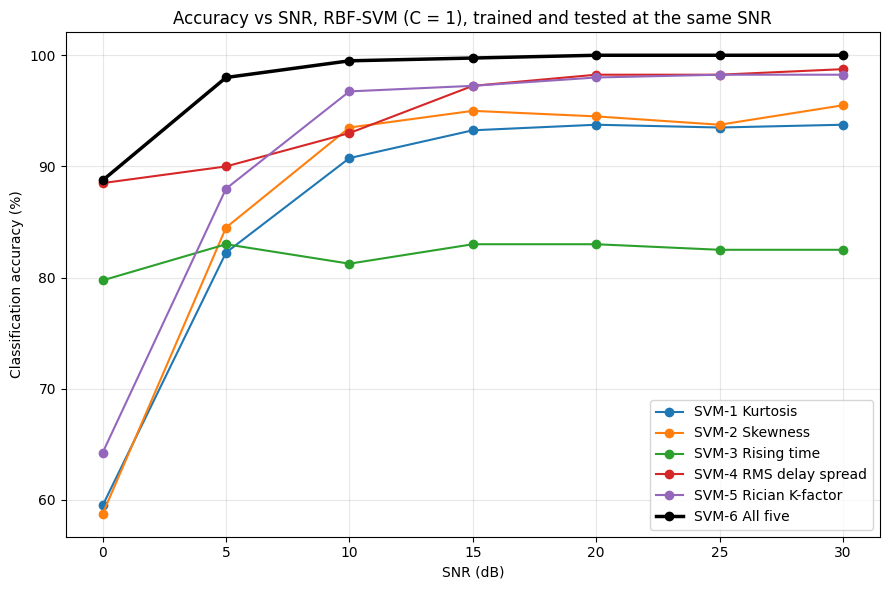

In [21]:
plt.figure(figsize=(9, 6))
for name in acc_b.columns:
    combined = name.startswith('SVM-6')
    plt.plot(acc_b.index, acc_b[name], marker='o',
             linewidth=2.5 if combined else 1.5,
             color='black' if combined else None, label=name)

plt.xlabel('SNR (dB)')
plt.ylabel('Classification accuracy (%)')
plt.title('Accuracy vs SNR, RBF-SVM (C = 1), trained and tested at the same SNR')
plt.xticks(SNR_LIST)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('part_b_accuracy.png', dpi=150)
plt.show()

In [22]:
# gain of the combined model over the best single feature
best_single = acc_b[[c for c in acc_b.columns if not c.startswith('SVM-6')]].max(axis=1)
(acc_b['SVM-6 All five'] - best_single).round(2)

snr_db
0     0.25
5     8.00
10    2.75
15    2.50
20    1.75
25    1.75
30    1.25
dtype: float64

## Part (c) - train at 25 dB, test everywhere

In [23]:
def fixed_model_curve(train_snr):
    # scaler is part of the frozen model, so it is fitted once and reused
    train, _ = split_at(train_snr)
    scaler = StandardScaler().fit(train[FEATURES])
    model = SVC(kernel='rbf', C=1).fit(scaler.transform(train[FEATURES]), train.label)

    scores = []
    for snr in SNR_LIST:
        _, test = split_at(snr)
        scores.append(100 * model.score(scaler.transform(test[FEATURES]), test.label))
    return model, scaler, pd.Series(scores, index=SNR_LIST)


model25, scaler25, curve25 = fixed_model_curve(25)

acc_c = pd.DataFrame({'Train = Test SNR': acc_b['SVM-6 All five'],
                      'Train at 25 dB': curve25})
acc_c.index.name = 'snr_db'
acc_c.round(2)

,Train = Test SNR,Train at 25 dB
snr_db,,
0,88.75,59.50
5,98.00,80.75
10,99.50,97.25
15,99.75,99.50
20,100.00,99.75
25,100.00,100.00
30,100.00,100.00


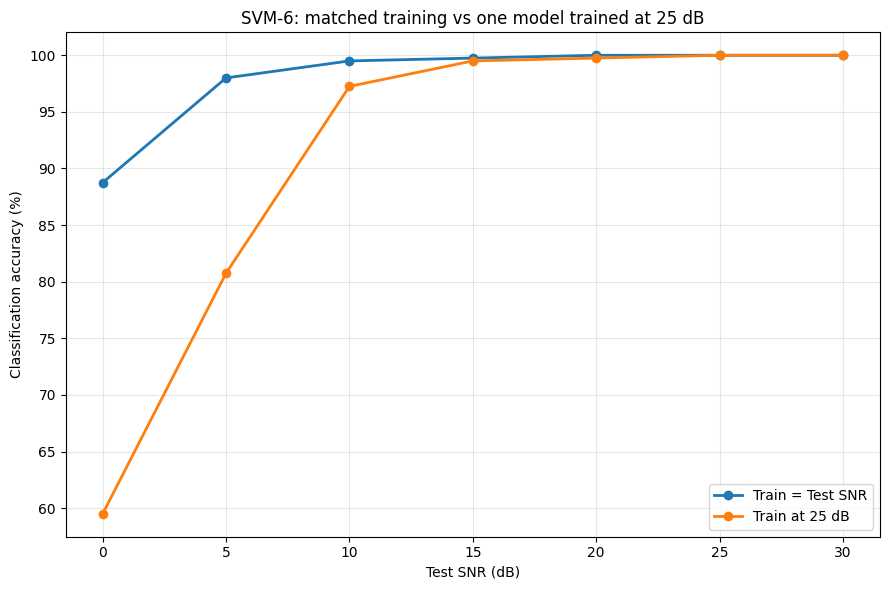

In [24]:
plt.figure(figsize=(9, 6))
for name in acc_c.columns:
    plt.plot(acc_c.index, acc_c[name], marker='o', linewidth=2, label=name)

plt.xlabel('Test SNR (dB)')
plt.ylabel('Classification accuracy (%)')
plt.title('SVM-6: matched training vs one model trained at 25 dB')
plt.xticks(SNR_LIST)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('part_c_accuracy.png', dpi=150)
plt.show()

In [25]:
# which class the fixed model gets wrong at low SNR
for snr in [0, 5, 10]:
    _, test = split_at(snr)
    cm = confusion_matrix(test.label, model25.predict(scaler25.transform(test[FEATURES])),
                          labels=[1, -1])
    print(f'{snr:2d} dB   LOS {cm[0,0]:3d}/{cm[0].sum()}   NLOS {cm[1,1]:3d}/{cm[1].sum()}')

 0 dB   LOS  38/200   NLOS 200/200
 5 dB   LOS 123/200   NLOS 200/200
10 dB   LOS 189/200   NLOS 200/200


In [26]:
# check for the last question: same model trained at 0 dB instead
_, _, curve0 = fixed_model_curve(0)
pd.DataFrame({'Train at 0 dB': curve0, 'Train at 25 dB': curve25}).round(2)

,Train at 0 dB,Train at 25 dB
0,88.75,59.50
5,92.25,80.75
10,90.25,97.25
15,91.50,99.50
20,91.75,99.75
25,90.50,100.00
30,90.00,100.00
